In [17]:
# Cargamos los imports

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, GRU, Dense, Input
from tensorflow.keras.optimizers import Adam

import random

np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

In [18]:
#  Creamos un dataset sintetico de clasificacion

# Sujetos
sujetos = [
    "la clase",
    "el curso",
    "la presentacion",
    "el sistema",
    "el modelo",
    "la red",
    "la explicacion",
    "el resultado",
    "la practica",
    "la sesion"
]

# Verbos / conectores
verbos = [
    "fue",
    "estuvo",
    "resulto",
    "parecio"
]

# Adjetivos positivos
positivos = [
    "excelente",
    "clara",
    "util",
    "ordenada",
    "brillante",
    "precisa",
    "interesante",
    "estable",
    "correcta",
    "eficiente"
]

# Adjetivos negativos
negativos = [
    "terrible",
    "confusa",
    "mala",
    "aburrida",
    "inestable",
    "incorrecta",
    "deficiente",
    "pesada",
    "desordenada",
    "pobre"
]

# Complementos opcionales
complementos = [
    "para el grupo",
    "durante la sesion",
    "en esta practica",
    "para el analisis",
    "segun los resultados",
    "en el laboratorio",
    "durante la clase",
    "para este problema",
    "en la evaluacion final",
    "segun el experimento"
]

frases=[]
etiquetas=[]
# Frases positivas
for _ in range(300):
  sujeto = random.choice(sujetos)
  verbo = random.choice(verbos)
  adj = random.choice(positivos)
  complemento = random.choice(complementos)
  frase = f"{sujeto} {verbo} {adj} {complemento}"
  frases.append(frase)
  etiquetas.append(1)

# Frases negativas
for _ in range(300):
  sujeto = random.choice(sujetos)
  verbo = random.choice(verbos)
  adj = random.choice(negativos)
  complemento = random.choice(complementos)
  frase = f"{sujeto} {verbo} {adj} {complemento}"
  frases.append(frase)
  etiquetas.append(0)

# Mezclamos
df = pd.DataFrame({
    "frase": frases,
    "etiqueta": etiquetas
})

df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print (df.head())
print ("\nTotal de ejemplos:",len(df))
print ("\nBalance de clases:")
print (df["etiqueta"].value_counts())

                                               frase  etiqueta
0     el curso resulto correcta segun los resultados         1
1      la practica fue deficiente para este problema         0
2  la presentacion estuvo incorrecta en la evalua...         0
3          el sistema resulto util en el laboratorio         1
4       el modelo resulto ordenada durante la sesion         1

Total de ejemplos: 600

Balance de clases:
etiqueta
1    300
0    300
Name: count, dtype: int64


In [19]:
# Dividimos en entrenamiento y prueba
X= df["frase"].tolist()
y= df["etiqueta"].tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Numero de frases de entrenamiento:", len(X_train))
print("Numero de frases de prueba:", len(X_test))

Numero de frases de entrenamiento: 480
Numero de frases de prueba: 120


In [20]:
# Tokenizar el texto

tokenizer= Tokenizer(oov_token="<OOV>")

tokenizer.fit_on_texts(X_train)

word_index = tokenizer.word_index

print( "Tamaño del voculabulario", len(word_index))
print("\nPrimeras palabras del vocabulario:")
for i, (palabra, indice) in enumerate(word_index.items()):
  if i >=15:
    break

  print(f"{palabra}:{indice}")

Tamaño del voculabulario 52

Primeras palabras del vocabulario:
<OOV>:1
la:2
el:3
para:4
en:5
resulto:6
fue:7
estuvo:8
parecio:9
segun:10
sesion:11
practica:12
durante:13
clase:14
este:15


In [21]:
# Convertimos texto a secuencias y le hacemos padding
X_train_seq= tokenizer.texts_to_sequences(X_train)
X_test_seq= tokenizer.texts_to_sequences(X_test)

max_len = max(len(seq) for seq in X_train_seq)

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding="post")
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len, padding="post")

vocab_size= len(word_index)+1

print("Forma X_train_pad:", X_train_pad.shape)
print("Forma X_test_pad:", X_test_pad.shape)
print("Longitud maxima:", max_len)

Forma X_train_pad: (480, 8)
Forma X_test_pad: (120, 8)
Longitud maxima: 8


In [23]:
# Modelo LSTM

embedding_dim = 16

modelo_lstm = Sequential()

modelo_lstm.add(Input(shape=(max_len,)))

modelo_lstm.add(
    Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim,
        mask_zero=True
    )
)
modelo_lstm.add(LSTM(16, recurrent_dropout=0.2))
modelo_lstm.add(Dense(1, activation="sigmoid"))

modelo_lstm.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)
modelo_lstm.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)         │ (None, 8, 16)          │           848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 16)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,977 (11.63 KB)

 Trainable params: 2,977 (11.63 KB)

 Non-trainable params: 0 (0.00 B)

In [25]:
# Modelo GRU

modelo_gru = Sequential()

modelo_gru.add(Input(shape=(max_len,)))

modelo_gru.add(
    Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim,
        mask_zero=True
    )
)
modelo_gru.add(GRU(16, recurrent_dropout=0.2))

modelo_gru.add(Dense(1, activation="sigmoid"))

modelo_gru.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)
modelo_gru.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_6 (Embedding)         │ (None, 8, 16)          │           848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 16)             │         1,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,497 (9.75 KB)

 Trainable params: 2,497 (9.75 KB)

 Non-trainable params: 0 (0.00 B)

In [26]:
# Entrenamos ambos modelos

# LSTM
hist_lstm = modelo_lstm.fit(
    X_train_pad,
    np.array(y_train),
    epochs=20,
    validation_split=0.2,
    verbose=0
)

# GRU
hist_gru = modelo_gru.fit(
    X_train_pad,
    np.array(y_train),
    epochs=20,
    validation_split=0.2,
    verbose=0
)

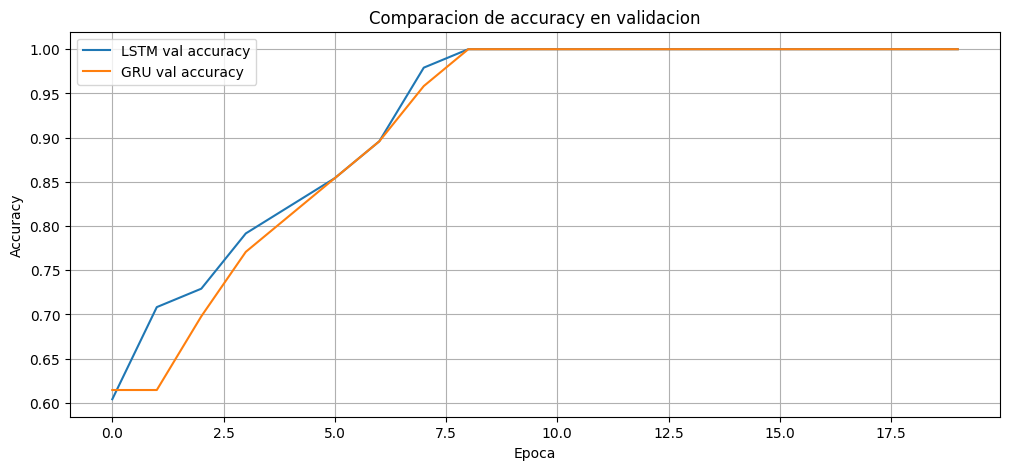

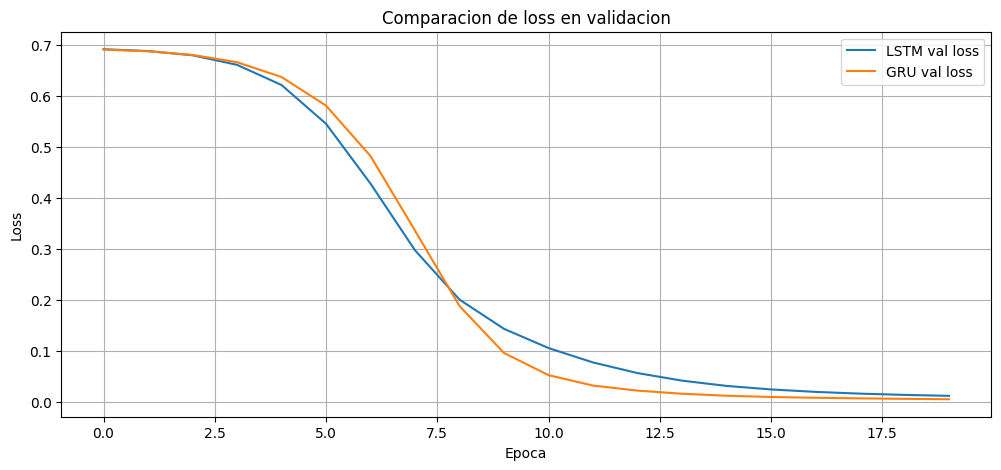

In [27]:
# Graficamos accury y loss

# Val accuracy
plt.figure(figsize=(12, 5))
plt.plot(hist_lstm.history["val_accuracy"], label="LSTM val accuracy")
plt.plot(hist_gru.history["val_accuracy"], label="GRU val accuracy")
plt.title("Comparacion de accuracy en validacion")
plt.xlabel("Epoca")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

# Loss
plt.figure(figsize=(12, 5))
plt.plot(hist_lstm.history["val_loss"], label="LSTM val loss")
plt.plot(hist_gru.history["val_loss"], label="GRU val loss")
plt.title("Comparacion de loss en validacion")
plt.xlabel("Epoca")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

In [29]:
# Evaluamos en test

# Evaluamos la LSTM
resultado_lstm = modelo_lstm.evaluate(X_test_pad, np.array(y_test),verbose=0)

# Evaluamos la GRU
resultado_gru = modelo_gru.evaluate(X_test_pad, np.array(y_test),verbose=0)

print("LSTM:")
print("Loss:", resultado_lstm[0])
print("Accuracy:", resultado_lstm[1])

print("\nGRU:")
print("Loss:", resultado_gru[0])
print("Accuracy:", resultado_gru[1])

LSTM:
Loss: 0.011595570482313633
Accuracy: 1.0

GRU:
Loss: 0.0049329656176269054
Accuracy: 1.0


In [30]:
# Probamos frases nuevas

frases_nuevas =[
    "el curso estuvo terrible para el grupo",
    "la explicacion resulto clara en el laboratorio",
    "el sistema parecio inestable segun los resultados",
    "la practica fue ordenada para este problema",
    "la sesion estuvo confusa en la evaluacion final"
]

seq_nuevas = tokenizer.texts_to_sequences(frases_nuevas)
pad_nuevas = pad_sequences(seq_nuevas, maxlen=max_len, padding="post")

pred_lstm = modelo_lstm.predict(pad_nuevas, verbose=0)

pred_gru = modelo_gru.predict(pad_nuevas, verbose=0)

print("Predicciones sobre nuevas frases:\n")
for i, frase in enumerate(frases_nuevas):
  print(f"Frase: {frase}")
  print(f" LSTM: {pred_lstm[i][0]:.4f}")
  print(f" GRU: {pred_gru[i][0]:.4f}")
  print("-"*70)

Predicciones sobre nuevas frases:

Frase: el curso estuvo terrible para el grupo
 LSTM: 0.0147
 GRU: 0.0074
----------------------------------------------------------------------
Frase: la explicacion resulto clara en el laboratorio
 LSTM: 0.9918
 GRU: 0.9971
----------------------------------------------------------------------
Frase: el sistema parecio inestable segun los resultados
 LSTM: 0.0139
 GRU: 0.0078
----------------------------------------------------------------------
Frase: la practica fue ordenada para este problema
 LSTM: 0.9916
 GRU: 0.9964
----------------------------------------------------------------------
Frase: la sesion estuvo confusa en la evaluacion final
 LSTM: 0.0105
 GRU: 0.0045
----------------------------------------------------------------------
